# 📊 Clase 2 — Elementos de un gráfico y buenas prácticas
### Diplomado en Visualización de Datos en R · Universidad del Valle

Hoy vamos a entender **cómo se construye un gráfico por dentro**, trabajar con datos reales desde Excel, recorrer el catálogo de gráficos más común (el mismo que verías en el panel de visualizaciones de Power BI) y aprender a distinguir un buen gráfico de uno malo.

**Recuerda:** Shift + Enter para ejecutar cada celda, en orden.

## 1. Variables, tipos de datos y funciones características de R

Antes de trabajar con datos reales, repasemos y ampliemos las funciones que R nos da para "preguntarle" cosas a nuestras variables.

## 2. Librerías

Hoy necesitamos dos paquetes: `tidyverse` (para manipular y graficar) y `readxl` (para leer archivos de Excel).

## 3. Data frames — con datos reales desde Excel

Vamos a trabajar con `ventas_ejemplo.xlsx`: ventas de una tienda por región, categoría y mes.

### Cómo subir el archivo a Colab
1. En el panel izquierdo, haz clic en el ícono de carpeta 📁
2. Clic en el ícono de subir archivo (una hoja con una flecha)
3. Selecciona `ventas_ejemplo.xlsx` desde tu computador
4. Espera a que termine de subir (aparece en la lista de archivos)

In [17]:
ventas <- read_excel("ventas_ejemplo.xlsx")
head(ventas)

mes,region,categoria,unidades_vendidas,ventas,meta_ventas
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Enero,Bogotá,Electrónica,75,12996,12992
Enero,Bogotá,Hogar,68,5108,4541
Enero,Bogotá,Ropa,88,4779,5221
Enero,Medellín,Electrónica,64,11347,10247
Enero,Medellín,Hogar,49,3826,3754
Enero,Medellín,Ropa,49,2963,2734


### Explorando el data frame

In [18]:
str(ventas)

tibble [90 × 6] (S3: tbl_df/tbl/data.frame)
 $ mes              : chr [1:90] "Enero" "Enero" "Enero" "Enero" ...
 $ region           : chr [1:90] "Bogotá" "Bogotá" "Bogotá" "Medellín" ...
 $ categoria        : chr [1:90] "Electrónica" "Hogar" "Ropa" "Electrónica" ...
 $ unidades_vendidas: num [1:90] 75 68 88 64 49 49 37 53 50 22 ...
 $ ventas           : num [1:90] 12996 5108 4779 11347 3826 ...
 $ meta_ventas      : num [1:90] 12992 4541 5221 10247 3754 ...


In [19]:
dim(ventas)      # filas, columnas

[1] 90  6

In [20]:
summary(ventas)  # estadísticas de cada columna numérica

        mes           region       categoria  unidades_vendidas     ventas     
 Length   :90   Length   :90   Length   :90   Min.   :15.00     Min.   : 1243  
 N.unique : 6   N.unique : 5   N.unique : 3   1st Qu.:40.00     1st Qu.: 3019  
 N.blank  : 0   N.blank  : 0   N.blank  : 0   Median :50.00     Median : 4166  
 Min.nchar: 4   Min.nchar: 4   Min.nchar: 4   Mean   :50.79     Mean   : 5249  
 Max.nchar: 7   Max.nchar:12   Max.nchar:11   3rd Qu.:61.00     3rd Qu.: 6966  
                                              Max.   :96.00     Max.   :14516  
  meta_ventas   
 Min.   : 1068  
 1st Qu.: 2819  
 Median : 3949  
 Mean   : 5068  
 3rd Qu.: 6760  
 Max.   :14864  

### El pipe con datos reales

Ejemplo: toma `ventas`, agrupa por región, y calcula el total vendido en cada una.

## 4. Los elementos de un gráfico — a fondo

Todo gráfico en `ggplot2` se construye en capas, siempre con la misma lógica:

```
ggplot(data = ..., aes(x = ..., y = ...)) +
  geom_algo() +
  labs(...)
```

Vamos a ver cada pieza por separado.

### `data` — de dónde vienen los datos
Es el data frame completo que le pasas a `ggplot()`. Todo lo demás se construye a partir de sus columnas.

### `aes()` — el mapeo estético
Le dice a R qué columna va en cada parte visual del gráfico:
- `x` → columna en el eje horizontal
- `y` → columna en el eje vertical
- `color` → columna que define el color de líneas/puntos
- `fill` → columna que define el color de relleno (barras, áreas)
- `size` → columna que define el tamaño (en dispersión)

No todos los gráficos necesitan todos estos argumentos — depende de qué quieras mostrar. Y esto es clave: **cada tipo de gráfico exige ciertos tipos de variable** (categórica, numérica, temporal). Lo vamos a señalar en cada uno.

### `geom_*()` — cómo se dibuja
Es la capa que decide la forma visual. Vamos a construir, uno por uno, el mismo catálogo que verías en el panel de visualizaciones de **Power BI** — y para cada uno, qué variables necesita.

#### 📊 Gráfico de barras — `geom_col()`
Para comparar totales entre categorías.

🧬 **Variables que usa:** 1 categórica (`region`) + 1 numérica (`total`). Ideal para comparar totales entre grupos.

#### 📈 Gráfico de líneas — `geom_line()`
Para mostrar una tendencia a lo largo del tiempo.

🧬 **Variables que usa:** 1 temporal/ordinal (`mes`) + 1 numérica (`total`). Ideal para mostrar evolución en el tiempo.

#### ⚬ Gráfico de dispersión — `geom_point()`
Para ver la relación entre dos variables numéricas.

🧬 **Variables que usa:** 2 numéricas (`unidades_vendidas`, `ventas`) + opcionalmente 1 categórica para color (`categoria`). Ideal para ver relación entre dos variables numéricas.

#### 📦 Boxplot — `geom_boxplot()`
Para comparar la distribución de una variable numérica entre grupos.

🧬 **Variables que usa:** 1 categórica (`categoria`) + 1 numérica (`ventas`). Ideal para comparar la distribución (no solo el total) entre grupos.

#### 📶 Histograma — `geom_histogram()`
Para ver cómo se distribuyen los valores de una sola variable numérica.

🧬 **Variables que usa:** 1 sola variable numérica (`ventas`). No necesita categórica — solo mira cómo se reparten los valores.

## 5. Más tipos de gráfico (el resto del catálogo de Power BI)

Si alguna vez has usado Power BI, estos son los íconos que ves en el panel de visualizaciones. Ya construimos los más usados en análisis (barras, líneas, dispersión, boxplot, histograma). Ahora vamos por los que suelen usarse más en **presentación**.

#### 🥧 Gráfico circular (pastel)

En `ggplot2` no existe un `geom_pie()` — se construye "doblando" una barra apilada en círculo con `coord_polar()`.

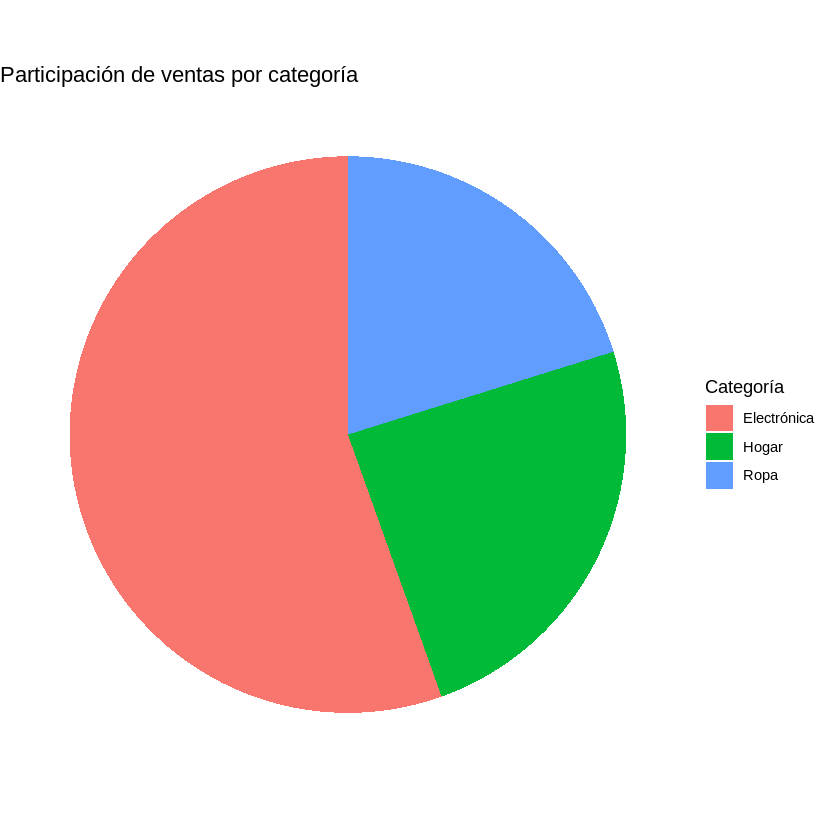

In [27]:
ventas_categoria <- ventas %>%
  group_by(categoria) %>%
  summarise(total = sum(ventas))

ggplot(data = ventas_categoria, aes(x = "", y = total, fill = categoria)) +
  geom_col(width = 1) +
  coord_polar("y") +
  labs(title = "Participación de ventas por categoría", fill = "Categoría") +
  theme_void()

🧬 **Variables que usa:** 1 categórica (`categoria`) + 1 numérica (`total`). Sirve para mostrar la **proporción** de cada categoría sobre el total — no para comparar valores exactos.

⚠️ **Cuidado con este gráfico:** el ojo humano compara ángulos peor que longitudes de barras. Úsalo solo con **pocas categorías** (máximo 4-5) y cuando el mensaje sea "qué tan grande es cada parte del total", no "cuál es exactamente mayor que cuál".

#### 🍩 Gráfico de dona

Es el mismo circular, con un agujero en el centro — el mismo truco de `coord_polar()`, agregando `xlim()`.

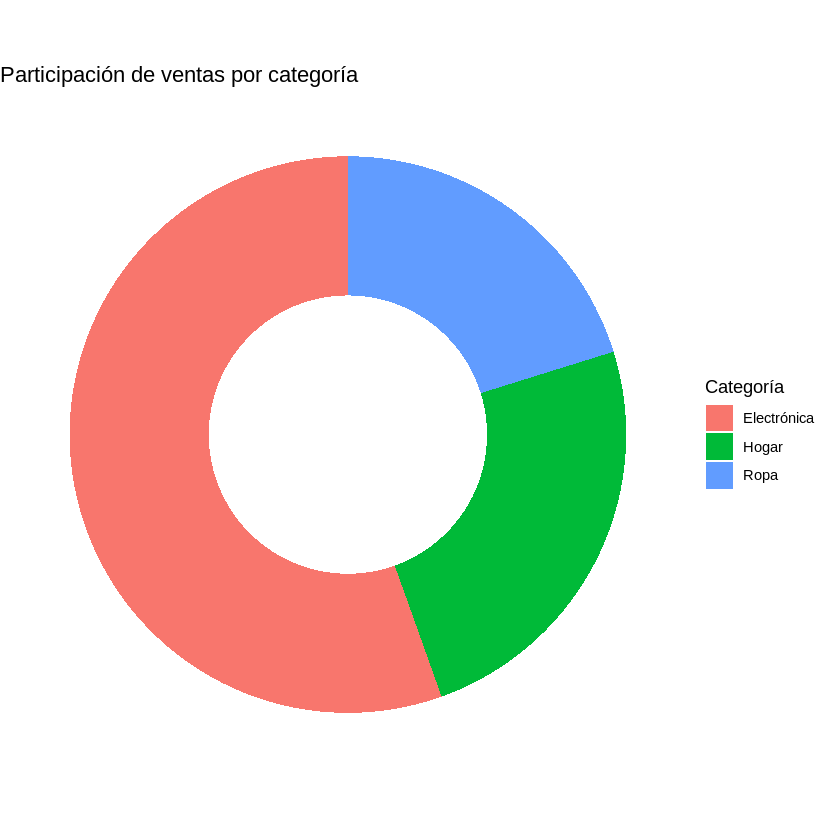

In [28]:
ggplot(data = ventas_categoria, aes(x = 2, y = total, fill = categoria)) +
  geom_col(width = 1) +
  coord_polar("y") +
  xlim(0.5, 2.5) +
  labs(title = "Participación de ventas por categoría", fill = "Categoría") +
  theme_void()

🧬 **Variables que usa:** las mismas que el circular (1 categórica + 1 numérica). Se usa por estética — dentro del hueco a veces se pone el total como número, algo que en R se logra combinándolo con otro elemento (lo verás con dashboards en Shiny).

#### 📊 Barras apiladas y barras agrupadas

Cuando quieres comparar totales **y** ver la composición interna de cada barra, agregas una segunda variable categórica en `fill`.

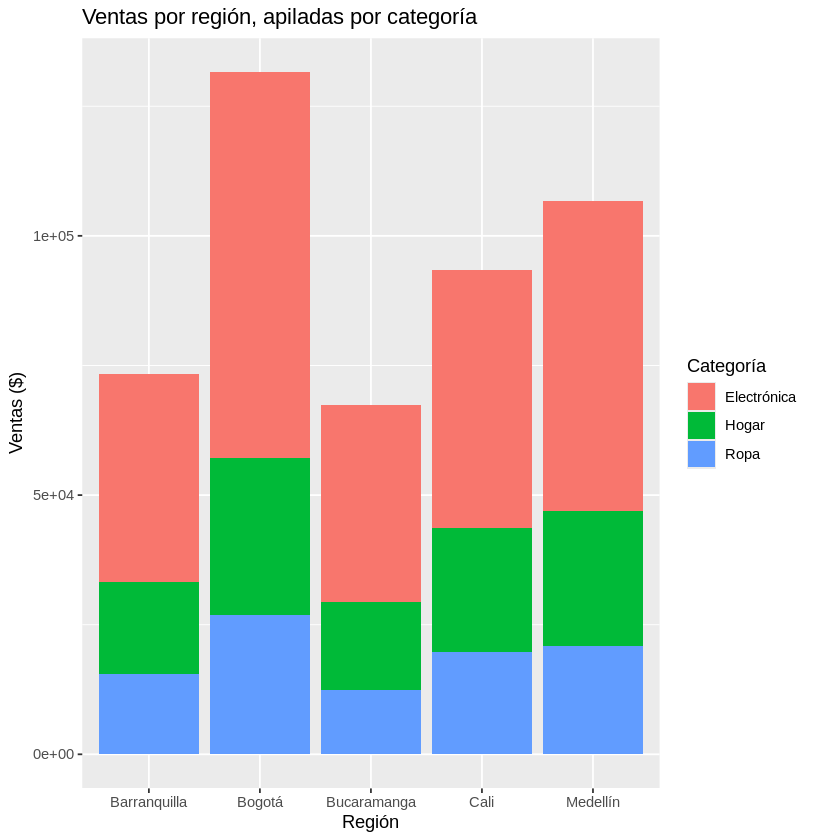

In [29]:
# Apiladas: position = "stack" (es el valor por defecto)
ggplot(data = ventas, aes(x = region, y = ventas, fill = categoria)) +
  geom_col(position = "stack") +
  labs(title = "Ventas por región, apiladas por categoría",
       x = "Región", y = "Ventas ($)", fill = "Categoría")

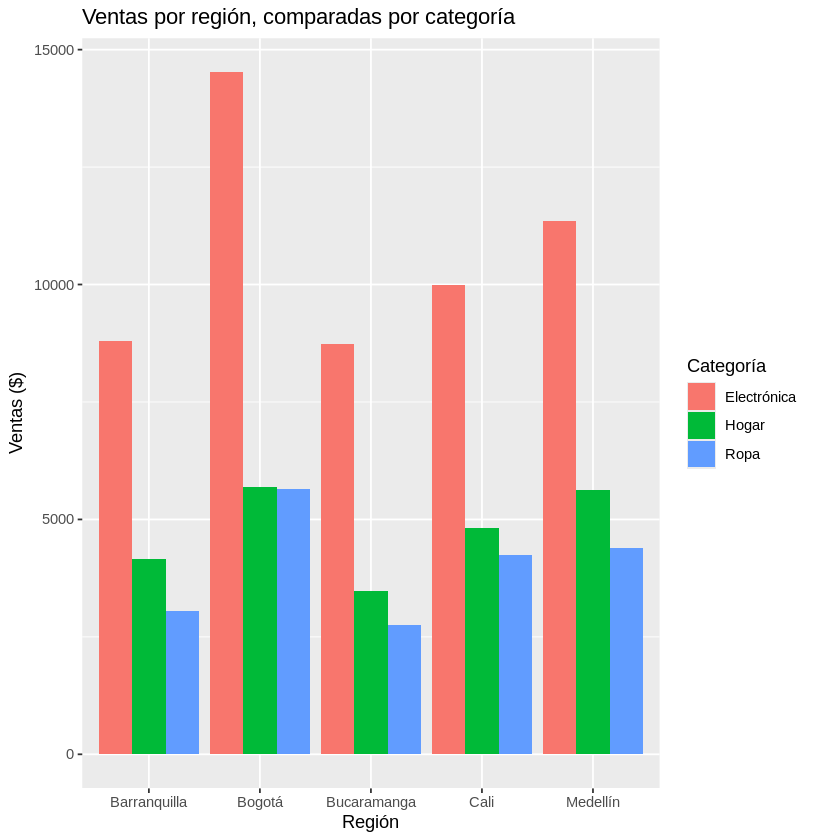

In [30]:
# Agrupadas: position = "dodge"
ggplot(data = ventas, aes(x = region, y = ventas, fill = categoria)) +
  geom_col(position = "dodge") +
  labs(title = "Ventas por región, comparadas por categoría",
       x = "Región", y = "Ventas ($)", fill = "Categoría")

🧬 **Variables que usa:** 2 categóricas (`region`, `categoria`) + 1 numérica (`ventas`). Apiladas = ves el total y la composición; agrupadas = comparas los valores exactos entre categorías, más fácil de leer con precisión.

#### 🏔️ Gráfico de área — `geom_area()`

Igual que líneas, pero rellenando el espacio debajo — resalta visualmente el volumen, no solo la tendencia.

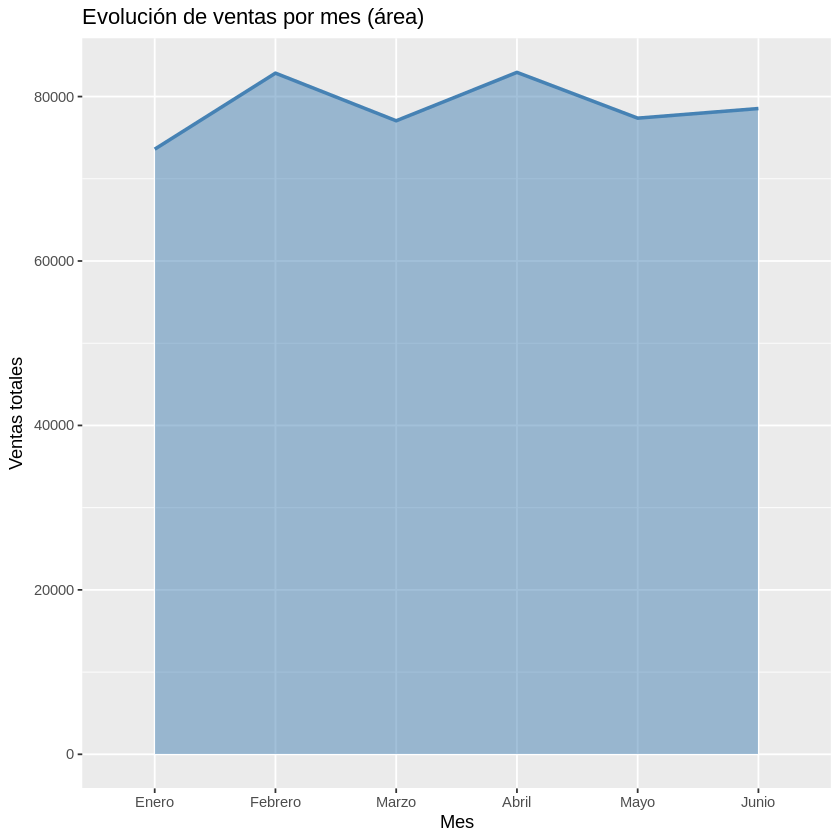

In [31]:
ggplot(data = ventas_mes, aes(x = mes, y = total, group = 1)) +
  geom_area(fill = "steelblue", alpha = 0.5) +
  geom_line(color = "steelblue", linewidth = 1) +
  labs(title = "Evolución de ventas por mes (área)",
       x = "Mes", y = "Ventas totales")

🧬 **Variables que usa:** igual que líneas — 1 temporal/ordinal + 1 numérica. Se usa cuando, además de la tendencia, quieres resaltar el volumen acumulado.

### Otros tipos que verás en Power BI, pero no construimos hoy

- **Mapa** — necesita datos geográficos (latitud/longitud o nombres de países/departamentos). En R se hace con paquetes como `leaflet` o `sf`; lo veremos si el proyecto de alguien lo requiere.
- **Treemap** — bueno para jerarquías con muchas categorías (rectángulos de tamaño proporcional). En R se construye con el paquete `treemapify`.
- **Tarjeta / KPI** — un solo número grande (ej. "Ventas totales: $500,000"). No es un gráfico de `ggplot2` — se construye directamente como elemento de un dashboard en Shiny.
- **Tabla/matriz** — a veces la mejor "visualización" es una tabla bien organizada con `summarise()`, sin forzar un gráfico.

### 🗂️ Resumen: qué gráfico usar según tus variables

| Gráfico | Variables que necesita | ¿Para qué sirve? |
|---|---|---|
| Barras / Columnas | 1 categórica + 1 numérica | Comparar totales entre grupos |
| Barras apiladas/agrupadas | 2 categóricas + 1 numérica | Comparar totales y ver composición |
| Líneas | 1 temporal + 1 numérica | Mostrar evolución en el tiempo |
| Área | 1 temporal + 1 numérica | Evolución + volumen acumulado |
| Dispersión | 2 numéricas (+1 categórica opcional) | Ver relación entre dos variables |
| Boxplot | 1 categórica + 1 numérica | Comparar distribución entre grupos |
| Histograma | 1 numérica | Ver cómo se distribuyen los valores |
| Circular / Dona | 1 categórica + 1 numérica | Proporción del total (pocas categorías) |
| Mapa | geográfica + 1 numérica | Datos por ubicación |
| Treemap | 1-2 categóricas + 1 numérica | Jerarquías con muchas categorías |
| Tarjeta / KPI | 1 numérica (agregada) | Resaltar un número clave |

Esta tabla es tu referencia rápida para el resto del diplomado: antes de elegir un gráfico, primero identifica qué tipos de variable tienes.

### `labs()` y un vistazo a `theme()` / `scale_fill_*()`

`labs()` controla los textos: título, subtítulo, nombres de ejes, leyenda.

`theme()` controla la apariencia general (fondo, tamaños de letra, posición de la leyenda), y `scale_fill_*()` / `scale_color_*()` controlan las paletas de color. Hoy solo necesitas saber que existen — los vamos a usar más a fondo en la Clase 3.

## 6. ¿Para qué entorno se usa cada gráfico?

Repasemos los gráficos de hoy, pero ahora pensando en quién los va a ver:

| Gráfico | Análisis (para ti) | Presentación (para otros) |
|---|---|---|
| Histograma | ✅ Ideal para explorar distribución rápido | Rara vez se usa así de crudo |
| Boxplot | ✅ Excelente para comparar grupos rápido | Se usa si la audiencia entiende estadística |
| Dispersión | ✅ Bueno para ver relaciones entre variables | Útil si la relación es el mensaje principal |
| Barras | Se puede usar, pero sin pulir | ✅ El más común para reportes ejecutivos |
| Barras apiladas | Útil para explorar composición | ✅ Muy usado en dashboards ejecutivos |
| Líneas | Se puede usar para explorar tendencia | ✅ El estándar para mostrar evolución en el tiempo |
| Área | Poco común en análisis | ✅ Impacto visual para tendencias en presentaciones |
| Circular / Dona | Poco útil, mejor usar barras | ✅ Solo con pocas categorías, para audiencias no técnicas |

La diferencia no está solo en el tipo de gráfico, sino en **cuánto lo pules**: título, colores con propósito, orden lógico, y una sola idea clara por gráfico.

##  Resumen de hoy

- ✅ Nuevas funciones de exploración: `length()`, `typeof()`, `str()`, `summary()`
- ✅ Cargar datos reales desde Excel con `read_excel()`
- ✅ Cada argumento de un gráfico explicado: `data`, `aes()`, `geom_*()`, `labs()`
- ✅ El catálogo completo de gráficos más comunes (como en Power BI), con las variables que necesita cada uno
- ✅ Cómo distinguir un buen gráfico de uno malo
- ✅ Para qué entorno usar cada tipo de gráfico

##  Ahora sigue la actividad

Abre el notebook **`Clase2_Actividad.ipynb`** — ahí vas a buscar tu propio dataset y aplicar todo lo de hoy.

---
*Diplomado en Visualización de Datos en R · Universidad del Valle*
*Docente: Sebastián Barrios Caracas*